# Binary Decisions from Continuous Data: Non-Bayesian Approaches


In {doc}`../07-bayesian-methods/optimal-decisions`, we considered optimal decision making in a discrete stochastic system (with discrete inputs and outputs) using a Bayesian framework. However, in many applications, the output of the system is continuous even if the input is discrete. For example, for a binary communication system, the input is bits, but the received noisy waveform is converted inside the receiver into a continuous random variable. Similarly, many medical tests for disease are based on chemical tests whose outputs are  continuous random variables. 

In this section, we consider scenarios in which the system input or hidden state is binary and the output is a continuous random variable. More specifically, we assume the data comes from one of two continuous densities, $f_0(x|H_0)$ or $f_1(x|H_1)$, and we wish to make a decision between $H_0$ and $H_1$ based on an observed value $x$. **Any** decision rule can then be written as follows. Let $\{R_0, R_1 \}$ be a partition of the real line. Then the decision rule is:
* If $x \in R_0$, decide $H_0$.
* If $x \in R_1$, decide $H_1$.

The regions $R_0$ and $R_1$ can be chosen to optimize some criteria that measures costs or rewards for making correct or erroneous decisions. Although $R_0$ and $R_1$ can generally be any Borel set, in practice they are often intervals that are determined by 
single threshold $\gamma$, like $R_0 = \{x|x < \gamma\}$ and $R_1 = \{x|x > \gamma\}$.



Consider a scenario where the *a priori* probabilities $P(H_0)$ and $P(H_1)$ are not known, and thus we cannot apply a Bayesian test. Then we might instead focus on determining $R_0$ and $R_1$ based on performance criteria that do not depend on these *a prioris*. In particular, we will use:
* the probability of false alarm, which we denote by $\alpha$, and
* the probability of miss, which we denote by $\beta$.

Let's introduce a concrete example to start to motivate our work:

**Example**

The PSA (Prostate-Specific Antigen) values for men in their 60s without cancer are approximately Gaussian(2,$\sigma=1$). The PSA values for men in their 60s with cancer are approximately Gaussian(4,$\sigma=1.5$).

Let $X$ denote the PSA value. Then the conditional densities for $X$ given $H_0$ and given $H_1$ are shown below:

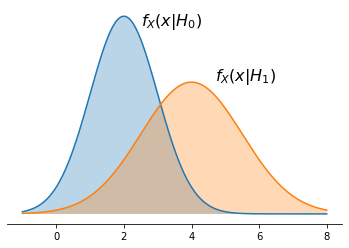

In [14]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt


G0 = stats.norm(loc = 2, scale = 1)
G1 = stats.norm(loc = 4, scale = 1.5)
x=np.linspace(-1,8,1001)


plt.plot(x,G0.pdf(x))
plt.plot(x,G1.pdf(x))

# Fill under the regions found above
plt.fill_between(x,G0.pdf(x),alpha=0.3)
plt.fill_between(x,G1.pdf(x),alpha=0.3)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

plt.annotate('$f_X(x|H_0)$', (2.5,0.38), fontsize=16)
plt.annotate('$f_X(x|H_1)$', (4.7,0.27), fontsize=16);

## Maximum Likelihood Decision Rule

Let's start by considering the maximum likelihood (ML) rule: 
* If $f_X(x|H_0) > f_X(x|H_1)$, decide $H_0$.
* If $f_X(x|H_0) \le f_X(x|H_1)$, decide $H_1$.

(Note that the deciding $H_1$ when $f_X(x|H_0) = f_X(x|H_1)$ is arbitrary and basically meaningless -- the probability of getting that exact value of $X$ is zero, because $X$ is a continuous random variable.)

We can determine the ML decision region corresponding to $H_0$ by finding the values of $x$ where  $f_X(x|H_0) > f_X(x|H_1)$:

In [21]:
x=np.linspace(-10,10, 1001)
x[np.where(G0.pdf(x) > G1.pdf(x))]

array([-2.28, -2.26, -2.24, -2.22, -2.2 , -2.18, -2.16, -2.14, -2.12,
       -2.1 , -2.08, -2.06, -2.04, -2.02, -2.  , -1.98, -1.96, -1.94,
       -1.92, -1.9 , -1.88, -1.86, -1.84, -1.82, -1.8 , -1.78, -1.76,
       -1.74, -1.72, -1.7 , -1.68, -1.66, -1.64, -1.62, -1.6 , -1.58,
       -1.56, -1.54, -1.52, -1.5 , -1.48, -1.46, -1.44, -1.42, -1.4 ,
       -1.38, -1.36, -1.34, -1.32, -1.3 , -1.28, -1.26, -1.24, -1.22,
       -1.2 , -1.18, -1.16, -1.14, -1.12, -1.1 , -1.08, -1.06, -1.04,
       -1.02, -1.  , -0.98, -0.96, -0.94, -0.92, -0.9 , -0.88, -0.86,
       -0.84, -0.82, -0.8 , -0.78, -0.76, -0.74, -0.72, -0.7 , -0.68,
       -0.66, -0.64, -0.62, -0.6 , -0.58, -0.56, -0.54, -0.52, -0.5 ,
       -0.48, -0.46, -0.44, -0.42, -0.4 , -0.38, -0.36, -0.34, -0.32,
       -0.3 , -0.28, -0.26, -0.24, -0.22, -0.2 , -0.18, -0.16, -0.14,
       -0.12, -0.1 , -0.08, -0.06, -0.04, -0.02,  0.  ,  0.02,  0.04,
        0.06,  0.08,  0.1 ,  0.12,  0.14,  0.16,  0.18,  0.2 ,  0.22,
        0.24,  0.26,

So we will decide $H_0$ if $-2.28 \le X \le 3.08$ and decide $H_1$ otherwise. Note, however, that $P(X<-2.28|H_i)$ is **very small** for both $H_0$ and $H_1$:

In [22]:
G0.pdf(-2.28), G1.pdf(-2.28)

(4.198750293161747e-05, 4.1555007345160996e-05)

Thus, a simpler decision region with similar performance is:
* Decide $H_0$ if $X \le 3.08$.
* Decide $H_1$ if $X > 3.08$.

Recall that a false alarm is when $H_0$ is true but the decision is $H_1$. Since $H_0$ is true, the probability a false alarm corresponds to some region under the curve $f_X(x|H_0)$. For the ML detection rule, that region is $\{x|x > 3.08\}$, and the false alarm probability is shown below:

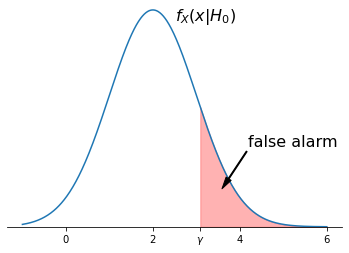

In [64]:
G0 = stats.norm(loc = 2, scale = 1)
x = np.linspace(-1,6,100*7+1)
fa_region = x[np.where(G1.pdf(x) >= G0.pdf(x))]
gamma = min(fa_region)

plt.plot(x,G0.pdf(x))

# Fill under the regions found above
plt.fill_between(fa_region, G0.pdf(fa_region), alpha=0.3, color='red')

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

ax.set_xticks([0,2,4,gamma,6])
ax.set_xticklabels([0,2,4,'$\gamma$',6])

ax.annotate('false alarm', xy=(gamma+0.5, 0.07),  xycoords='data',
            xytext=(6.25, 0.17), textcoords='data', fontsize=16,
            arrowprops=dict(facecolor='black', headwidth=6, width=1),
            horizontalalignment='right', verticalalignment='top',
            )

plt.annotate('$f_X(x|H_0)$', (2.5,0.38), fontsize=16)
plt.ylim(0, 0.4);


Similarly, a miss is when $H_1$ is true, but the decision is $H_0$. The figure below illustrates the region under the conditional density $f_X(x|H_1)$ that corresponds to the probability of miss:

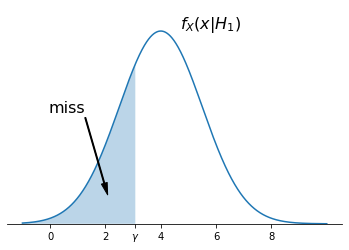

In [80]:

G1 = stats.norm(loc = 4, scale = 1.5)
x=np.linspace(-1,10,11*100+1)
miss_region = x[np.where(G1.pdf(x) < G0.pdf(x))]
gamma = max(miss_region)

plt.plot(x,G1.pdf(x))

# Fill under the regions found above
plt.fill_between(miss_region, G1.pdf(miss_region),alpha=0.3)



ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

ax.set_xticks([0,2,4,gamma,6, 8])
ax.set_xticklabels([0,2,4,'$\gamma$',6, 8])

ax.annotate('miss', xy=(gamma-1, 0.04),  xycoords='data',
            xytext=(1.25, 0.17), textcoords='data', fontsize=16,
            arrowprops=dict(facecolor='black', headwidth=6, width=1),
            horizontalalignment='right', verticalalignment='top',
            )

plt.annotate('$f_X(x|H_1)$', (4.7,0.27), fontsize=16);
plt.ylim(0, 0.3);

Note that both the probability of false alarm ($\alpha$) and the probability of miss ($\beta$) are tail probabilities of a Normal distribution. Thus, we can easily calculate their values using the $Q$ function:

In [81]:
def q(x):
  return stats.norm.sf(x)

In [95]:
# False alarm: Given H0, mu = 2 and sigma = 1
mu0 = 2
sigma0 =1

gamma = 3.08
alpha = q( (gamma - mu0) / sigma0)
alpha

0.140071090088769

In [96]:
# Miss: Given H1, mu = 4 and sigma = 1.5
mu1 = 4
sigma1 = 1.5

gamma = 3.08
beta = q( (mu1 - gamma) / sigma1)
beta

0.26982797857981605

## Performance Tradeoffs

The ML rule gives us one pair of values for $\alpha$ and $\beta$. However, we can generate different pairs of $\alpha, \beta$ by using the same rule but varying the decision threshold, $\gamma$. For example, the figure below shows the false alarm and miss probability regions for $\gamma=2$:


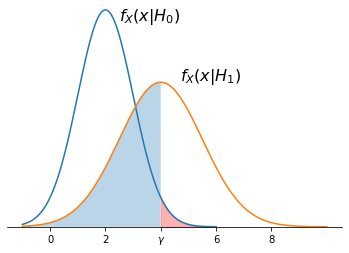

In [94]:
gamma = 4


G0 = stats.norm(loc = 2, scale = 1)
x = np.linspace(-1,6,100*7+1)
fa_region = x[np.where(x>gamma)]
gamma = min(fa_region)

plt.plot(x,G0.pdf(x))

# Fill under the regions found above
plt.fill_between(fa_region, G0.pdf(fa_region), alpha=0.3, color='red')

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

ax.set_xticks([0,2,4,gamma,6])
ax.set_xticklabels([0,2,4,'$\gamma$',6])

# ax.annotate('false alarm', xy=(gamma+0.5, 0.07),  xycoords='data',
#             xytext=(6.25, 0.17), textcoords='data', fontsize=16,
#             arrowprops=dict(facecolor='black', headwidth=6, width=1),
#             horizontalalignment='right', verticalalignment='top',
#             )

plt.annotate('$f_X(x|H_0)$', (2.5,0.38), fontsize=16)
plt.ylim(0, 0.4);


G1 = stats.norm(loc = 4, scale = 1.5)
x=np.linspace(-1,10,11*100+1)
miss_region = x[np.where(x<gamma)]

plt.plot(x,G1.pdf(x))

# Fill under the regions found above
plt.fill_between(miss_region, G1.pdf(miss_region),alpha=0.3)



ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

ax.set_xticks([0,2,gamma,6, 8])
ax.set_xticklabels([0,2,'$\gamma$',6, 8])

# ax.annotate('miss', xy=(gamma-1, 0.04),  xycoords='data',
#             xytext=(1.25, 0.17), textcoords='data', fontsize=16,
#             arrowprops=dict(facecolor='black', headwidth=6, width=1),
#             horizontalalignment='right', verticalalignment='top',
#             )

plt.annotate('$f_X(x|H_1)$', (4.7,0.27), fontsize=16);
plt.ylim(0, 0.4);

By using a larger value of $\gamma$, the probability of false alarm is reduced, while the probability of miss is increased:

In [97]:
gamma = 4

# False alarm: Given H0, mu = 2 and sigma = 1
mu0 = 2
sigma0 =1


alpha = q( (gamma - mu0) / sigma0)

# Miss: Given H1, mu = 4 and sigma = 1.5
mu1 = 4
sigma1 = 1.5

beta = q( (mu1 - gamma) / sigma1)

alpha, beta

(0.022750131948179195, 0.5)

If a lower probability of miss is desired, the decision threshold can be decreased. the figure below shows the false alarm and miss probability regions for $\gamma=2$:

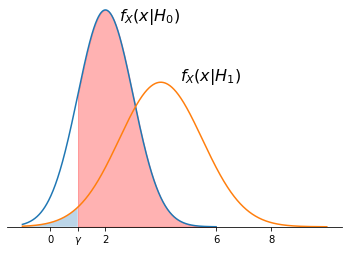

In [99]:
gamma = 1


G0 = stats.norm(loc = 2, scale = 1)
x = np.linspace(-1,6,100*7+1)
fa_region = x[np.where(x>gamma)]
gamma = min(fa_region)

plt.plot(x,G0.pdf(x))

# Fill under the regions found above
plt.fill_between(fa_region, G0.pdf(fa_region), alpha=0.3, color='red')

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

ax.set_xticks([0,2,4,gamma,6])
ax.set_xticklabels([0,2,4,'$\gamma$',6])

# ax.annotate('false alarm', xy=(gamma+0.5, 0.07),  xycoords='data',
#             xytext=(6.25, 0.17), textcoords='data', fontsize=16,
#             arrowprops=dict(facecolor='black', headwidth=6, width=1),
#             horizontalalignment='right', verticalalignment='top',
#             )

plt.annotate('$f_X(x|H_0)$', (2.5,0.38), fontsize=16)
plt.ylim(0, 0.4);


G1 = stats.norm(loc = 4, scale = 1.5)
x=np.linspace(-1,10,11*100+1)
miss_region = x[np.where(x<gamma)]

plt.plot(x,G1.pdf(x))

# Fill under the regions found above
plt.fill_between(miss_region, G1.pdf(miss_region),alpha=0.3)



ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([]);

ax.set_xticks([0,2,gamma,6, 8])
ax.set_xticklabels([0,2,'$\gamma$',6, 8])

# ax.annotate('miss', xy=(gamma-1, 0.04),  xycoords='data',
#             xytext=(1.25, 0.17), textcoords='data', fontsize=16,
#             arrowprops=dict(facecolor='black', headwidth=6, width=1),
#             horizontalalignment='right', verticalalignment='top',
#             )

plt.annotate('$f_X(x|H_1)$', (4.7,0.27), fontsize=16);
plt.ylim(0, 0.4);

The probability of false alarm and miss for $\gamma=2$ are

In [101]:
gamma = 2

# False alarm: Given H0, mu = 2 and sigma = 1
mu0 = 2
sigma0 =1


alpha = q( (gamma - mu0) / sigma0)

# Miss: Given H1, mu = 4 and sigma = 1.5
mu1 = 4
sigma1 = 1.5

beta = q( (mu1 - gamma) / sigma1)

alpha, beta

(0.5, 0.09121121972586788)

### Illlustrating Performance Tradeoffs: ROC Curves

A common way to illustrated the tradeoff between probability of false alarm and probability of miss is through a ROC curve. ROC stands for Receiver Operating Characteristic, and were originally developed for detecting objects in RADAR signals. A ROC curve plots the probability of false alarm (sometimes called the False Positive Rate, or FPR) versus the probability of detection (sometimes called the True Positive Rate, or TPR). Here, the probability of detection is $1-\beta$. A ROC curve is usually generated by sweeping the threshold, $\gamma$, over a region that essentially covers $0 \le \alpha \le 1$ and $0\le \beta \le 1$, recording the pairs $\alpha, 1-\beta$, and then generating a line plot of the probability of detection as a function of the probability of false alarm.


The code below generates a ROC curve for this example

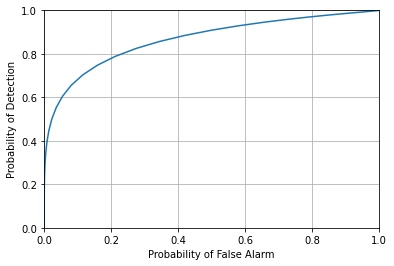

In [137]:
num_gammas = 101

gammas = np.linspace(-10, 10, num_gammas)
# False alarm: Given H0, mu = 2 and sigma = 1
mu0 = 2
sigma0 =1

# Miss: Given H1, mu = 4 and sigma = 1.5
mu1 = 4
sigma1 = 1.5

alphas = np.zeros(num_gammas)
betas = np.zeros(num_gammas)

for i, gamma in enumerate(gammas):
  alphas[i] = q( (gamma - mu0) / sigma0)
  betas[i] = q( (mu1 - gamma) / sigma1)


plt.plot(alphas, 1-betas)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel('Probability of False Alarm');
plt.ylabel('Probability of Detection');
plt.grid();

If we don't use the observed value of $X$ at all, then if we guess $H_1$ with probability $p$, then the probability of false alarm will be $p$ (since when $H_0$ is true, we will still choose $H_1$ probability $p$), and the probability of detection will also be $p$ (since, when $H_1$ is true, we also decide $H_1$ with probability $p$). Thus, without using the observed value, we get a linear relation between $\alpha$ and $1-\beta$. Sometimes this is shown as a reference on the ROC curve:

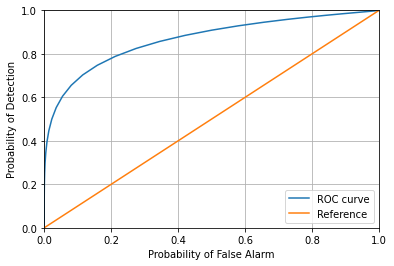

In [136]:
num_gammas = 101

gammas = np.linspace(-10, 10, num_gammas)
# False alarm: Given H0, mu = 2 and sigma = 1
mu0 = 2
sigma0 =1

# Miss: Given H1, mu = 4 and sigma = 1.5
mu1 = 4
sigma1 = 1.5

alphas = np.zeros(num_gammas)
betas = np.zeros(num_gammas)

for i, gamma in enumerate(gammas):
  alphas[i] = q( (gamma - mu0) / sigma0)
  betas[i] = q( (mu1 - gamma) / sigma1)


plt.plot(alphas, 1-betas, label='ROC curve')
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel('Probability of False Alarm');
plt.ylabel('Probability of Detection');

p=np.linspace(0, 1, num_gammas)
plt.plot(p, p, label='Reference');
plt.legend();
plt.grid();

The further the ROC curve is from the reference (in terms of being more toward the upper left-hand corner), the better performance of the detector. I.e., it is able to achieve a higher $1-\beta$ for a given $\alpha$, or vice versa. 

### Quantifying Detector Performance: Area Under the Curve (AUC)

We can quantify the performance of the detector by integrating the area under the ROC curve. The closer the ROC curve is to the upper left-hand corner, the higher the integral will be. This is called the *Area Under Curve (AUC)*. We have seen that random guessing yields the diagonal reference line, and the area under the reference line is 1/2.  If a detector makes perfect decisions, then it can achieve a probability of detection of $1-\beta = 1$ with probability of false alarm $\alpha=0$, so the ideal ROC curve rises instantly from 0 to 1 and then remains at 1. The area under the ideal ROC curve is thus 1. We can compute the area under the ROC for our example by using NumPy's `np.trapz()` numerical integration routine. It is important to note that depending on the form of the detector, the $\alpha$ values may come out in reverse numerical order:

In [126]:
alphas

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 9.99999999e-01, 9.99999997e-01,
       9.99999989e-01, 9.99999967e-01, 9.99999900e-01, 9.99999713e-01,
       9.99999207e-01, 9.99997888e-01, 9.99994587e-01, 9.99986654e-01,
       9.99968329e-01, 9.99927652e-01, 9.99840891e-01, 9.99663071e-01,
       9.99312862e-01, 9.98650102e-01, 9.97444870e-01, 9.95338812e-01,
       9.91802464e-01, 9.86096552e-01, 9.77249868e-01, 9.64069681e-01,
       9.45200708e-01, 9.19243341e-01, 8.84930330e-01, 8.41344746e-01,
      

Whenever that is the case, we need to use `np.flip()` on both vectors to put them in the correct order. We pass the flipped `alphas` vector as the `x` keyword parameter and the flipped `1-betas` vector as the `y` keyword parameter of `np.trapz()`. (**Do NOT omit the keyword names because the default order is y, x, which will be confusing to most people.**) The final command is shown at the end of the code block below:

In [127]:
num_gammas = 101

gammas = np.linspace(-10, 10, num_gammas)
# False alarm: Given H0, mu = 2 and sigma = 1
mu0 = 2
sigma0 =1

# Miss: Given H1, mu = 4 and sigma = 1.5
mu1 = 4
sigma1 = 1.5

alphas = np.zeros(num_gammas)
betas = np.zeros(num_gammas)

for i, gamma in enumerate(gammas):
  alphas[i] = q( (gamma - mu0) / sigma0)
  betas[i] = q( (mu1 - gamma) / sigma1)
  
np.trapz(x = np.flip(alphas), y = np.flip(1-betas) )

0.865881144229319

### Neyman-Pearson Detection

Neyman-Pearson detection formalizes making the trade-off between $\alpha$ and $\beta$ in the following way: Given a required value of $\alpha$, Neyman-Pearson detection chooses the decision regions $R_0, R_1$ to minimize the probability of miss. Let's find the Neyman-Pearson decision rule for $\alpha=0.1$ when the decision regions are constrained to be of the form $R_0: \{x| x < \gamma \}$ and $R_1: \{x| x \ge \gamma\}$.  We can use the ROC curve to get the approximate value of $1- \beta \approx 0.7$, or $\beta =0.3$. Let's see how we can get the same result analytically.

For $\alpha < 0.5$, the probability of false alarm will be the probability of an upper tail of the form $P(X>\gamma|H_0)$, which is 
\begin{align*}
P(X>\gamma|H_0) & = Q \left( \frac{\gamma - \mu_0}{\sigma_0} \right) \\
&= Q \left(\gamma -2 \right) = 0.1.
\end{align*}

We can solve for $\gamma$ by taking $Q^{-1}$ of both sides:
\begin{align*}
\gamma -2 &= Q^{-1} (0.1) \\
\gamma  &= 2+ Q^{-1} (0.1) \\
\end{align*}

Let's create a `qinv()` function as an alias for `stats.norm.isf()`:

In [130]:
def qinv(p):
  return stats.norm.isf(p)

In [132]:
gamma_np =2+qinv(0.1)
gamma_np

3.2815515655446004

Then the probability of false alarm is $P(X< \gamma|H_1)$, which is
\begin{align*}
P(X<\gamma|H_1) & = Q \left( \frac{ \mu_1 -\gamma}{\sigma_1} \right) \\
&= Q \left(\frac{4-\gamma}{1.5} \right).
\end{align*}

The result is computed below:

In [134]:
q((4-gamma_np)/1.5)

0.31598154244181886

The analytical result is very close to our estimate from the ROC curve.

## Exercise

1. Plot the performance if the variance of each PSA test is reduced by a factor of 4. What is the AUC?

0.9892938656914673

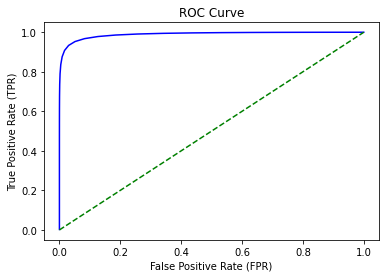

In [140]:
ref=np.linspace(0,1,50)
fpr=[]
tpr=[]
for gamma in np.linspace(0,6,50):
    fpr+=[q((gamma-2)/np.sqrt(1/4))]
    tpr+=[1-q((4-gamma)/np.sqrt(2/4))]
plt.plot(fpr,tpr,'b',ref,ref,'g--');
plt.xlabel('False Positive Rate (FPR)'); 
plt.ylabel('True Positive Rate (TPR)');
plt.title('ROC Curve');
np.trapz(np.flip(tpr),x=np.flip(fpr))

2. If the variance of each PSA test is reduced by a factor of 2 (from the original values), what is the decision threshold for $\alpha=0.1$? What value of $\beta$ is achieved?